# Evrişimli Sinir Ağları (CNN) — MNIST ile Adım Adım

Bu notebook, CNN'in temel kavramlarını MNIST el yazısı rakam veri seti üzerinde açıklayarak öğretmektedir.

## İçerik
1. Kütüphaneler ve Sabitler
2. Veri Seti: MNIST
3. Veriyi Görselleştirme
4. CNN Mimarisi — Katman Katman Açıklama
5. Model Eğitimi
6. Test ve Değerlendirme
7. Tahmin Örnekleri
8. Evrişim Filtrelerini Görselleştirme

---

## 1. Kütüphaneler ve Sabitler

PyTorch'un temel modülleri:
- **`torch.nn`** → sinir ağı katmanları (Conv2d, Linear, vb.)
- **`torchvision`** → hazır veri setleri ve dönüşümler
- **`DataLoader`** → veriyi mini-batch'ler halinde sunar

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np


# ── SABİTLER ─────────────────────────────────────────────
BATCH_SIZE   = 128
EPOCHS       = 15
LEARNING_RATE = 0.001

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# GPU varsa kullan, yoksa CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan cihaz: {DEVICE}")
print(f"PyTorch sürümü : {torch.__version__}")

Kullanılan cihaz: cuda
PyTorch sürümü : 2.10.0+cu128


## 2. Veri Seti: MNIST

**MNIST** → 70 000 el yazısı rakam görüntüsü (0–9)
- Eğitim: 60 000 örnek  
- Test   : 10 000 örnek  
- Görüntü boyutu: **28 × 28 piksel, gri tonlamalı (1 kanal)**

### Normalizasyon Neden Gerekli?

Ham piksel değerleri 0–255 arasındadır. Bunları **[0,1]** aralığına çekip ardından
**standartlaştırıyoruz** (ortalama=0.1307, std=0.3081 — MNIST'e özgü değerler).  
Böylece gradyanlar dengeli kalır ve eğitim daha hızlı yakınsar.

In [ ]:


# ── DATA AUGMENTATION + NORMALIZATION ────────────────────
train_transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=train_transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=test_transform
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)


print(f"Eğitim örneği : {len(train_dataset)}")
print(f"Test örneği   : {len(test_dataset)}")
print(f"Batch sayısı  : {len(train_loader)}  (eğitim)")

Eğitim örneği : 60000
Test örneği   : 10000
Batch sayısı  : 469  (eğitim)


## 3. Veriyi Görselleştirme

Modeli kurmadan önce veriye bakmak iyi bir alışkanlıktır.
- Her görüntü **tek kanallı (gri)** ve **28×28** pikseldir.
- Etiketler 0–9 arasında tam sayılardır.

Batch tensör şekli : torch.Size([128, 1, 28, 28])
Etiket şekli       : torch.Size([128])


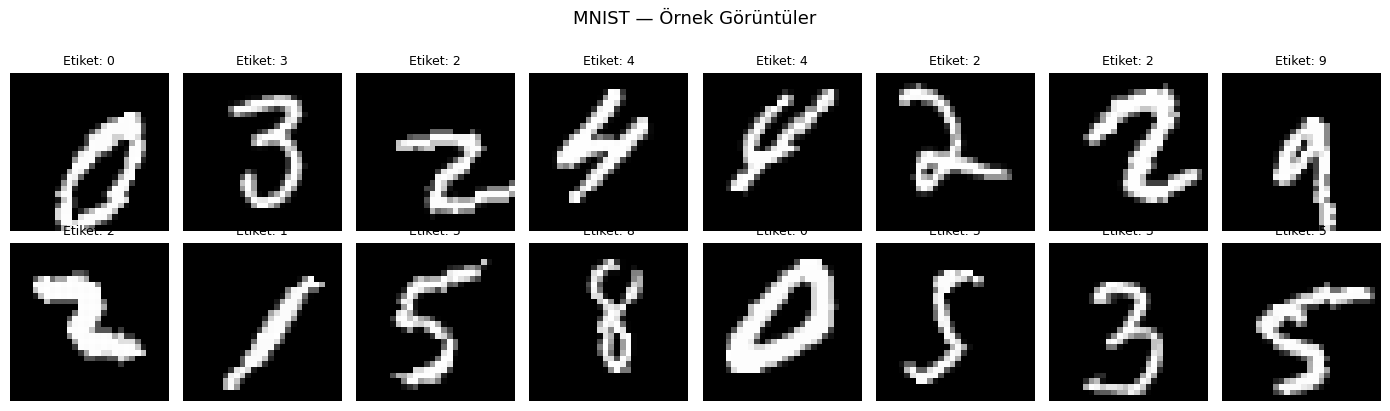

In [ ]:
# İlk batch'i al
images, labels = next(iter(train_loader))
print(f"Batch tensör şekli : {images.shape}")  # [64, 1, 28, 28]
print(f"Etiket şekli       : {labels.shape}")  # [64]

# 16 örnek göster
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flatten()):
    # Normalize edilmiş görüntüyü tekrar [0,1]'e çek (sadece görselleştirme için)
    img = images[i].squeeze().numpy()
    img = (img * 0.3081) + 0.1307          # ters normalizasyon
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Etiket: {labels[i].item()}", fontsize=9)
    ax.axis('off')
plt.suptitle("MNIST — Örnek Görüntüler", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. CNN Mimarisi — Katman Katman Açıklama

### CNN Neden Görüntüler için Uygun?

Düz (Fully Connected) katmanlar pikselleri bağımsız değerler olarak işler.  
CNN ise **yerel örüntüleri** (kenar, köşe, doku) öğrenen **filtreler** kullanır ve
konumsaldan bağımsız (translation-invariant) özellikler çıkarır.

### Kullanacağımız Mimari

```
Giriş: [B, 1, 28, 28]        ← B: batch boyutu

── Blok 1 ──────────────────────────────────────────
Conv2d(1→32, kernel=3, pad=1)  → [B, 32, 28, 28]   ← 32 filtre öğrenir
ReLU                                                ← negatif aktivasyonları sıfırlar
MaxPool2d(2)                   → [B, 32, 14, 14]   ← boyutu yarıya indirir

── Blok 2 ──────────────────────────────────────────
Conv2d(32→64, kernel=3, pad=1) → [B, 64, 14, 14]
ReLU
MaxPool2d(2)                   → [B, 64,  7,  7]

── Sınıflandırıcı (FC) ──────────────────────────────
Flatten                        → [B, 64×7×7] = [B, 3136]
Linear(3136 → 128)  + ReLU    → [B, 128]
Dropout(0.5)                   ← aşırı öğrenmeyi engeller
Linear(128 → 10)               → [B, 10]    ← 10 sınıf (0–9)
```

### Anahtar Kavramlar

| Kavram | Açıklama |
|---|---|
| **Conv2d** | Görüntü üzerinde kayan filtre — kenar/doku öğrenir |
| **kernel_size=3** | 3×3 piksellik alan her seferinde incelenir |
| **padding=1** | Kenar pikseller kaybolmasın diye sıfır ekler |
| **ReLU** | f(x)=max(0,x) — doğrusal olmayan aktivasyon |
| **MaxPool2d** | 2×2 bölgedeki en büyük değeri alır, boyutu düşürür |
| **Dropout** | Eğitimde rastgele nöronları kapatır (regularizasyon) |
| **Linear** | Klasik tam bağlantılı katman |

In [ ]:

# ── GELİŞMİŞ CNN ─────────────────────────────────────────
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2, 2)

        self.dropout_conv = nn.Dropout2d(0.25)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout_fc = nn.Dropout(0.5)

        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.dropout_conv(x)

        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout_conv(x)

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout_fc(x)

        x = self.fc2(x)
        return x


model = CNN().to(DEVICE)

# ── LOSS + OPTIMIZER (weight decay eklendi) ─────────────
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

# ── LR SCHEDULER ─────────────────────────────────────────
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

# ── TRAINING ─────────────────────────────────────────────
for epoch in range(1, EPOCHS + 1):

    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # ── TEST ────────────────────────────────────────────
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)

            preds = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    acc = 100 * correct / total
    print(f"Epoch {epoch} | Loss: {running_loss/len(train_loader):.4f} | Acc: {acc:.2f}%")

    # 🔥 scheduler step
    scheduler.step()

print("Eğitim tamamlandı!")

Epoch 1 | Loss: 0.6267 | Acc: 98.13%
Epoch 2 | Loss: 0.3113 | Acc: 98.39%
Epoch 3 | Loss: 0.2601 | Acc: 98.86%
Epoch 4 | Loss: 0.2287 | Acc: 98.93%
Epoch 5 | Loss: 0.2044 | Acc: 98.92%
Eğitim tamamlandı!


## 4.1 Kayıp Fonksiyonu ve Optimizasyon

| Bileşen | Seçim | Neden? |
|---|---|---|
| **Kayıp fonksiyonu** | `CrossEntropyLoss` | Çok sınıflı sınıflandırmada standart — içinde softmax barındırır |
| **Optimizatör** | `Adam` | Adaptif öğrenme oranı, hızlı yakınsama |

### Geri Yayılım (Backpropagation) Adımları
```
1. İleri geçiş  → tahmin üret
2. Kaybı hesapla (loss)
3. optimizer.zero_grad()  → önceki gradyanları temizle
4. loss.backward()        → gradyanları hesapla
5. optimizer.step()       → ağırlıkları güncelle
```

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Kayıp fonksiyonu : {criterion}")
print(f"Optimizatör      : {optimizer.__class__.__name__}, lr={LEARNING_RATE}")

Kayıp fonksiyonu : CrossEntropyLoss()
Optimizatör      : Adam, lr=0.001


## 5. Model Eğitimi

Her **epoch** (tur):
1. Tüm eğitim verisi mini-batch'ler halinde modelden geçirilir.
2. Her batch sonrası ağırlıklar güncellenir.
3. Epoch sonunda **test kaybı** ve **doğruluk** hesaplanır.

> `model.train()` → dropout aktif  
> `model.eval()`  → dropout pasif, gradyan hesabı yok

In [ ]:
train_losses, test_losses, test_accuracies = [], [], []

for epoch in range(1, EPOCHS + 1):

    # ── EĞİTİM ──────────────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()          # 1. Gradyanları sıfırla
        outputs = model(images)        # 2. İleri geçiş
        loss    = criterion(outputs, labels)  # 3. Kaybı hesapla
        loss.backward()                # 4. Geri yayılım
        optimizer.step()               # 5. Ağırlıkları güncelle

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ── TEST ────────────────────────────────────────────────────────────────
    model.eval()
    test_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():              # Gradyan hesabı gerekmez → hız + bellek tasarrufu
        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            test_loss += criterion(outputs, labels).item()

            predicted = outputs.argmax(dim=1)   # En yüksek logit = tahmin
            total    += labels.size(0)
            correct  += (predicted == labels).sum().item()

    avg_test_loss = test_loss / len(test_loader)
    accuracy      = 100.0 * correct / total
    test_losses.append(avg_test_loss)
    test_accuracies.append(accuracy)

    print(f"Epoch [{epoch}/{EPOCHS}]  "
          f"Eğitim Kaybı: {avg_train_loss:.4f}  "
          f"Test Kaybı: {avg_test_loss:.4f}  "
          f"Test Doğruluk: {accuracy:.2f}%")

print("\nEğitim tamamlandı!")

Epoch [1/5]  Eğitim Kaybı: 0.1966  Test Kaybı: 0.0290  Test Doğruluk: 99.14%
Epoch [2/5]  Eğitim Kaybı: 0.1771  Test Kaybı: 0.0266  Test Doğruluk: 99.17%
Epoch [3/5]  Eğitim Kaybı: 0.1609  Test Kaybı: 0.0239  Test Doğruluk: 99.28%
Epoch [4/5]  Eğitim Kaybı: 0.1530  Test Kaybı: 0.0230  Test Doğruluk: 99.25%
Epoch [5/5]  Eğitim Kaybı: 0.1437  Test Kaybı: 0.0228  Test Doğruluk: 99.23%

Eğitim tamamlandı!


## 6. Eğitim Grafiği

- **Kayıp azalıyorsa** model öğreniyor demektir.
- Eğitim kaybı test kaybının **çok altına** düşerse → **aşırı öğrenme (overfitting)**.
- İyi bir modelde iki eğri birbirine yakın seyreder.

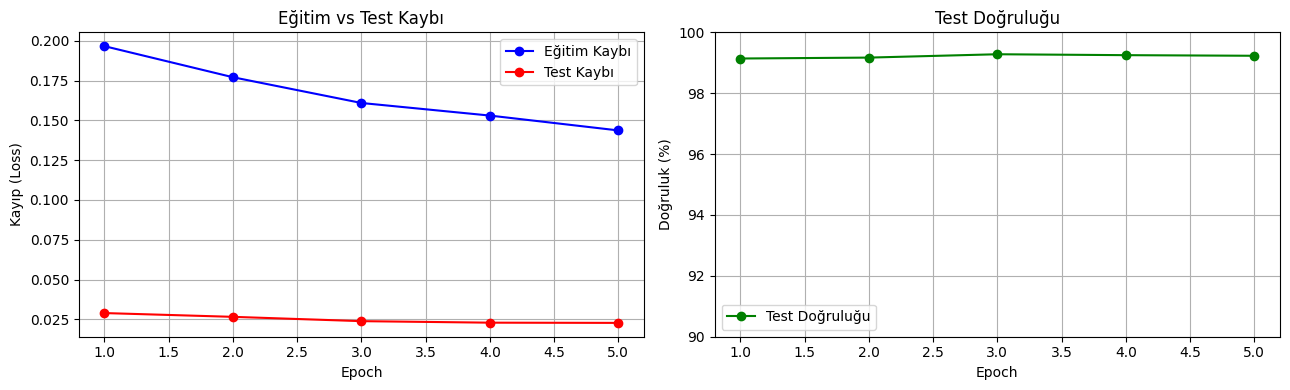

En yüksek test doğruluğu: 99.28%


In [ ]:
epochs_range = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Kayıp eğrisi
ax1.plot(epochs_range, train_losses, 'b-o', label='Eğitim Kaybı')
ax1.plot(epochs_range, test_losses,  'r-o', label='Test Kaybı')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Kayıp (Loss)')
ax1.set_title('Eğitim vs Test Kaybı')
ax1.legend()
ax1.grid(True)

# Doğruluk eğrisi
ax2.plot(epochs_range, test_accuracies, 'g-o', label='Test Doğruluğu')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Doğruluk (%)')
ax2.set_title('Test Doğruluğu')
ax2.legend()
ax2.grid(True)
ax2.set_ylim([90, 100])

plt.tight_layout()
plt.show()
print(f"En yüksek test doğruluğu: {max(test_accuracies):.2f}%")

## 7. Tahmin Örnekleri

Modelin doğru ve **yanlış** tahmin ettiği örnekleri görselleştiriyoruz.
- **Yeşil başlık** → doğru tahmin  
- **Kırmızı başlık** → yanlış tahmin (gerçek etiket de gösterilir)

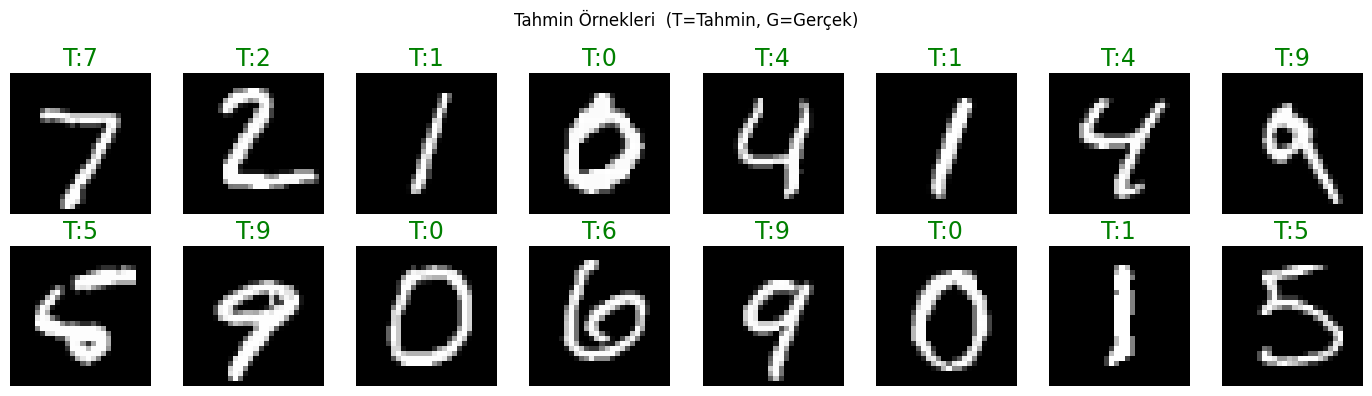

In [ ]:
model.eval()

# Tüm test öngörülerini topla
all_images, all_preds, all_labels = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu()
        all_images.append(images.cpu())
        all_preds.append(preds)
        all_labels.append(labels)

all_images = torch.cat(all_images)
all_preds  = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

# İlk 16 örneği göster
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flatten()):
    img   = all_images[i].squeeze().numpy()
    img   = (img * 0.3081) + 0.1307
    pred  = all_preds[i].item()
    label = all_labels[i].item()
    correct_flag = (pred == label)

    ax.imshow(img, cmap='gray')
    title_color = 'green' if correct_flag else 'red'
    title_text  = f"T:{pred}" if correct_flag else f"T:{pred}\nG:{label}"
    ax.set_title(title_text, color=title_color, fontsize=17)
    ax.axis('off')


plt.suptitle("Tahmin Örnekleri  (T=Tahmin, G=Gerçek)", fontsize=12)
plt.subplots_adjust(top=0.8)
plt.tight_layout()
plt.show()

## 7.1 Karışıklık Matrisi (Confusion Matrix)

Her satır gerçek sınıfı, her sütun tahmin edilen sınıfı gösterir.  
Köşegen üzerindeki değerler **doğru** tahminlerdir.

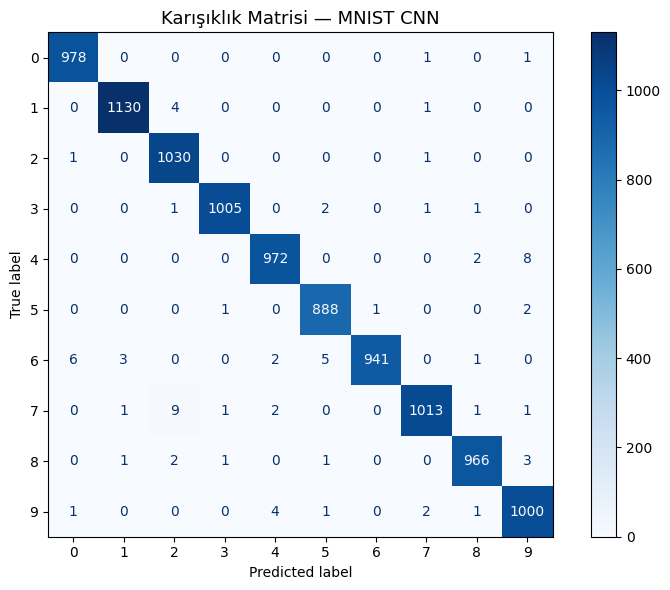

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels.numpy(), all_preds.numpy())

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=list(range(10)))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Karışıklık Matrisi — MNIST CNN', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
!

## 8. Evrişim Filtrelerini Görselleştirme

Birinci evrişim katmanının (**conv1**) 32 filtresi ne öğrendi?  
- Filtrelerin ağırlıklarını doğrudan görselleştiriyoruz.  
- İlk katmanda genellikle **kenar algılayıcılar** (dikey, yatay, çapraz) oluşur.

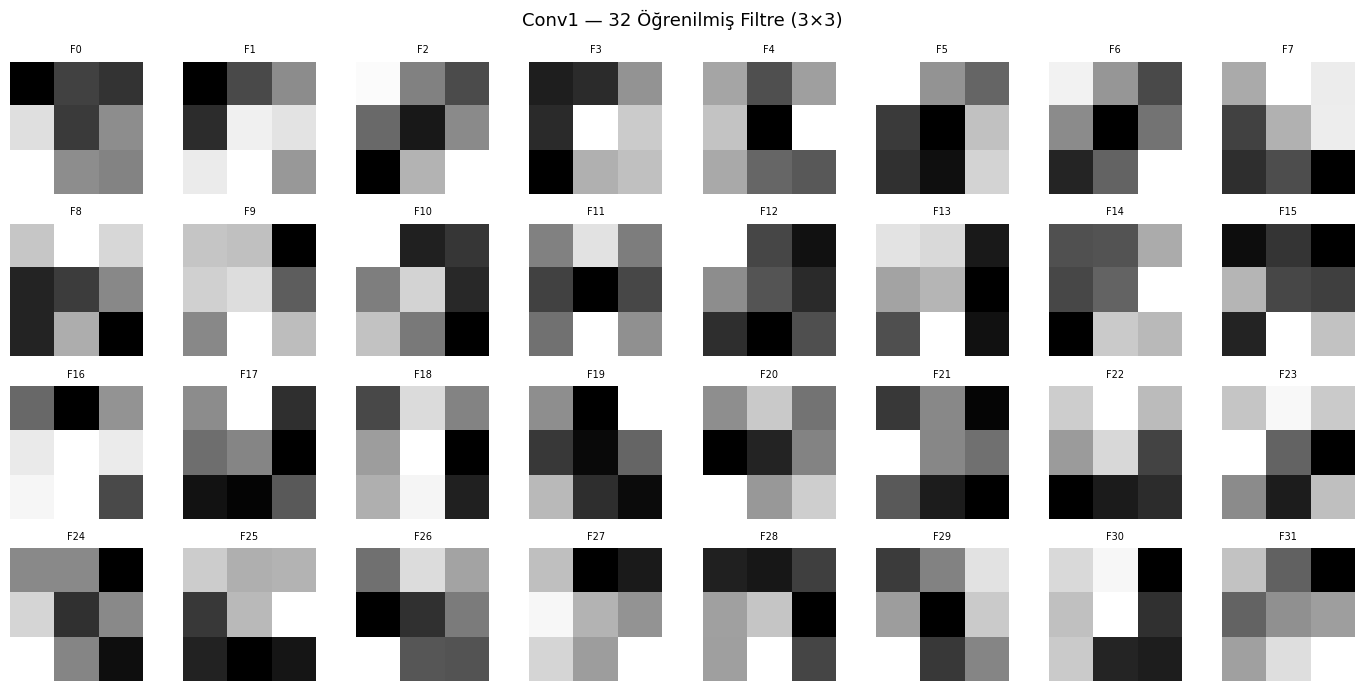

In [ ]:
filters = model.conv1.weight.data.cpu()  # şekil: [32, 1, 3, 3]

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flatten()):
    f = filters[i, 0].numpy()            # tek kanallı 3×3 filtre
    # Görüntüleme için [0,1] aralığına normalize et
    f = (f - f.min()) / (f.max() - f.min() + 1e-8)
    ax.imshow(f, cmap='gray', interpolation='nearest')
    ax.set_title(f"F{i}", fontsize=7)
    ax.axis('off')

plt.suptitle("Conv1 — 32 Öğrenilmiş Filtre (3×3)", fontsize=13)
plt.tight_layout()
plt.show()

## 8.1 Özellik Haritaları (Feature Maps)

Tek bir görüntü conv1'den geçince oluşan **32 özellik haritasını** görüyoruz.  
Her harita, filtreden gelen aktivasyonu temsil eder.

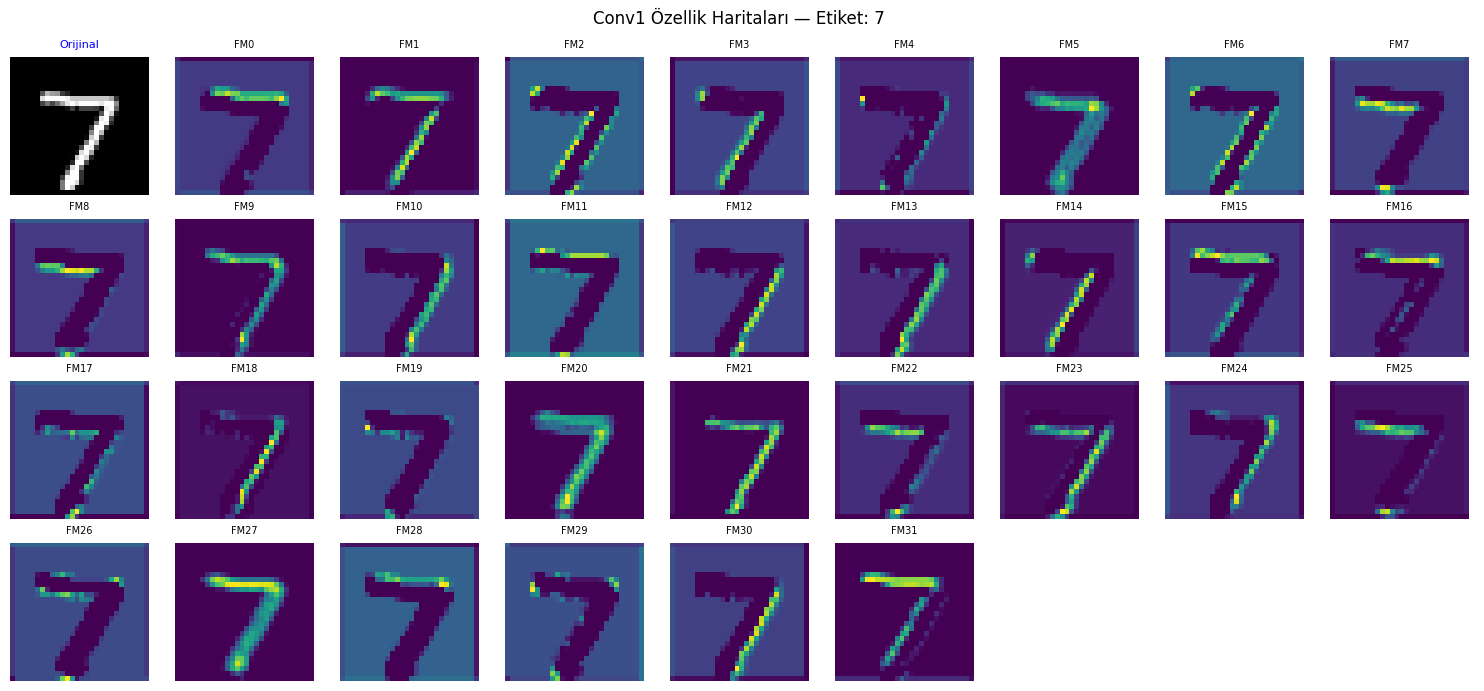

In [ ]:
# Tek bir görüntüyü seç
sample_image = all_images[0].unsqueeze(0).to(DEVICE)  # [1,1,28,28]

# Sadece conv1 + ReLU çıktısını al (ara katman aktivasyonu)
model.eval()
with torch.no_grad():
    feature_maps = F.relu(model.conv1(sample_image))  # [1,32,28,28]

feature_maps = feature_maps.squeeze(0).cpu()          # [32,28,28]

# Orijinal görüntü
fig, axes = plt.subplots(4, 9, figsize=(15, 7))

# Sol üst köşeye orijinal görüntü
orig = all_images[0].squeeze().numpy()
orig = (orig * 0.3081) + 0.1307
axes[0, 0].imshow(orig, cmap='gray')
axes[0, 0].set_title('Orijinal', fontsize=8, color='blue')
axes[0, 0].axis('off')

# 32 özellik haritası
fm_axes = [axes[r, c] for r in range(4) for c in range(9) if not (r == 0 and c == 0)]
for i, ax in enumerate(fm_axes[:32]):
    fm = feature_maps[i].numpy()
    ax.imshow(fm, cmap='viridis')
    ax.set_title(f"FM{i}", fontsize=7)
    ax.axis('off')

# Kalan boş hücreleri kapat
for ax in fm_axes[32:]:
    ax.axis('off')

plt.suptitle(f"Conv1 Özellik Haritaları — Etiket: {all_labels[0].item()}", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
!pip install ipycanvas -q

In [ ]:
from google.colab import output
output.enable_custom_widget_manager()

In [ ]:
import cv2
import numpy as np
from ipywidgets import Button
from ipycanvas import Canvas
from IPython.display import display, clear_output

canvas = Canvas(width=300, height=200, sync_image_data=True)
canvas.line_width = 20
canvas.stroke_style = "black"
canvas.fill_style = "white"
canvas.fill_rect(0, 0, 300, 200)
display(canvas)

drawing = False

def on_mouse_down(x, y):
    global drawing
    drawing = True
    canvas.begin_path()
    canvas.move_to(x, y)

def on_mouse_move(x, y):
    if drawing:
        canvas.line_to(x, y)
        canvas.stroke()

def on_mouse_up(x, y):
    global drawing
    drawing = False

def predict(key):
    # 1. Canvas'tan RGBA verisini al
    rgba_data = canvas.get_image_data()

    # 2. Grayscale'e çevir (300x200)
    gray = cv2.cvtColor(rgba_data, cv2.COLOR_RGBA2GRAY)

    # 3. 28x28'e yeniden boyutlandır (MNIST formatı)
    resized = cv2.resize(gray, (28, 28), interpolation=cv2.INTER_AREA)


    # 4. Rengi ters çevir: canvas siyah rakam/beyaz arka plan çizer,
    #    MNIST ise beyaz rakam/siyah arka plan kullanır
    resized = 255 - resized

    # 5. [0,1] aralığına normalize et ve tensöre çevir
    tensor = torch.from_numpy(resized).float() / 255.0

    # 6. Eğitimde kullanılan MNIST normalizasyonunu uygula
    tensor = (tensor - 0.1307) / 0.3081
    tensor = tensor.unsqueeze(0).unsqueeze(0).to(DEVICE)


    # 7. (1, 784) şekline getir ve cihaza taşı
    #tensor = tensor.view(1, -1)

    # 8. Tahmin yap (eval modu: Dropout kapalı, BatchNorm sabit)
    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1)

    predicted_digit = probs.argmax(dim=1).item()
    confidence      = probs[0, predicted_digit].item() * 100

    clear_output(wait=True)
    display(canvas)
    display(btn)
    print(f"Tahmin    : {predicted_digit}")
    print(f"Güven     : {confidence:.1f}%")
    print(f"Olasılıklar: {[f'{p:.3f}' for p in probs[0].tolist()]}")

canvas.on_mouse_down(on_mouse_down)
canvas.on_mouse_move(on_mouse_move)
canvas.on_mouse_up(on_mouse_up)

btn = Button(description='Tahmin Et')
btn.on_click(callback=predict)
display(btn)

Canvas(height=200, image_data=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x00\xc8\x08\x06\x00\x…

Button(description='Tahmin Et', style=ButtonStyle())

Tahmin    : 0
Güven     : 99.8%
Olasılıklar: ['0.998', '0.000', '0.000', '0.000', '0.000', '0.000', '0.000', '0.000', '0.002', '0.000']


## Özet

| Adım | Ne Yaptık? |
|---|---|
| Veri hazırlama | MNIST indirildi, normalizasyon uygulandı, DataLoader kuruldu |
| CNN mimarisi | 2 evrişim bloğu + MaxPool + FC katmanları |
| Eğitim | CrossEntropyLoss + Adam optimizörü, 5 epoch |
| Değerlendirme | Test doğruluğu ~%99, karışıklık matrisi |
| Görselleştirme | Öğrenilmiş filtreler ve özellik haritaları |

### Daha İleri Gitmek İçin
- Batch Normalization ekle (`nn.BatchNorm2d`)
- Data Augmentation (dönme, kaydırma) dene
- Daha derin ağ: ResNet, VGG mimarileri incele
- CIFAR-10 gibi renkli ve daha zor bir veri setine geç